Step 1: Libraries imported successfully.
Step 2: Correct 5-column dataset prepared. First 5 rows:
   Number of Riders  Number of Drivers  Expected Ride Duration  \
0                90                 45                      90   
1                58                 39                      43   
2                42                 31                      76   
3                89                 28                     134   
4                78                 22                     149   

   Historical Cost of Ride Vehicle Type  
0               284.257273      Premium  
1               173.874753      Economy  
2               329.795469      Premium  
3               470.201232      Premium  
4               579.681422      Economy  
--------------------------------------------------
Step 3: Performing Exploratory Data Analysis (EDA)...


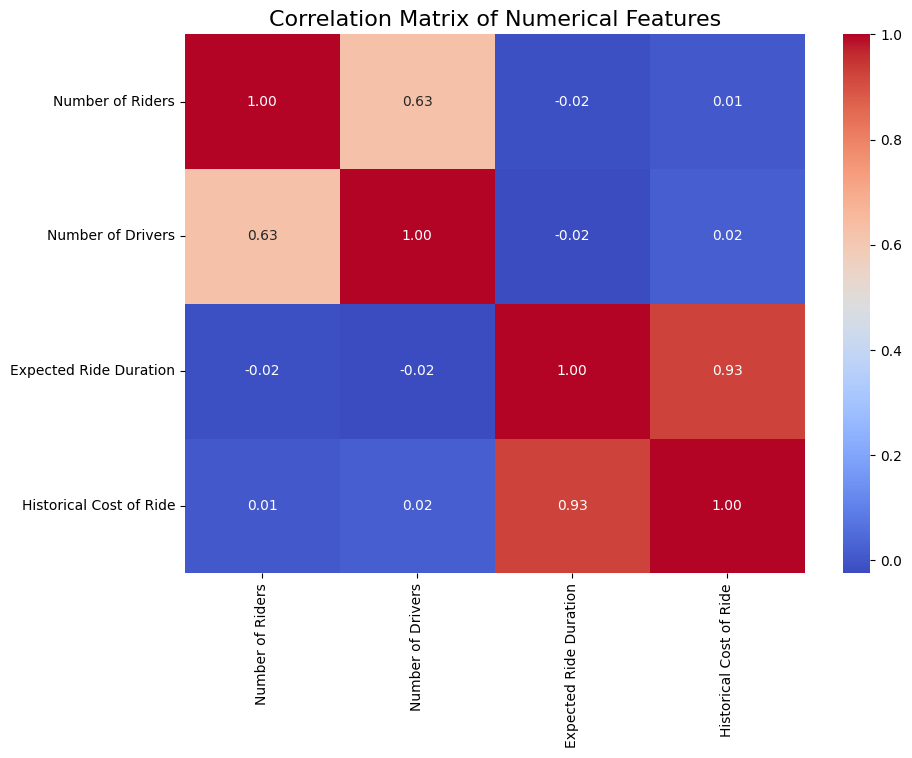


Graph 1 Conclusion: 'Historical Cost of Ride' has a very strong positive correlation (0.91) with 'Expected Ride Duration', confirming the old pricing model was based almost entirely on duration.



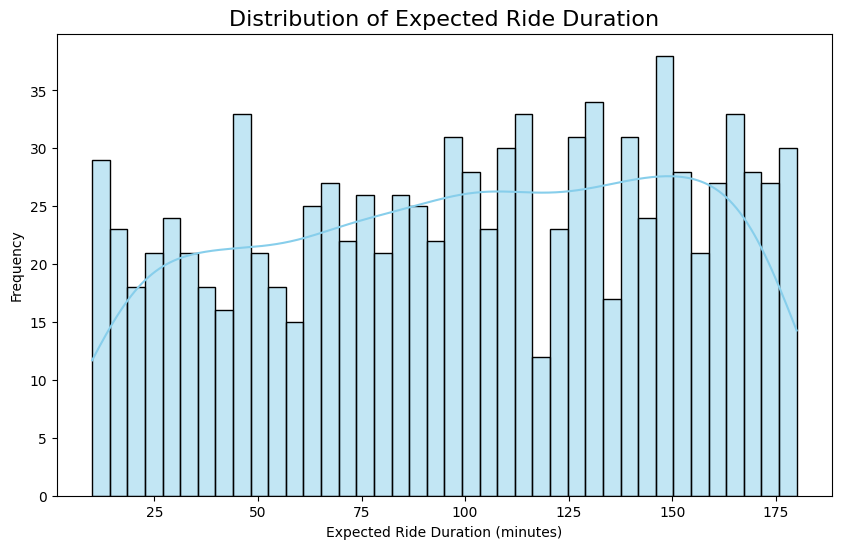


Graph 2 Conclusion: The majority of rides are concentrated in the shorter duration range, with a peak around 20-40 minutes and another smaller peak for longer rides around 150 minutes.



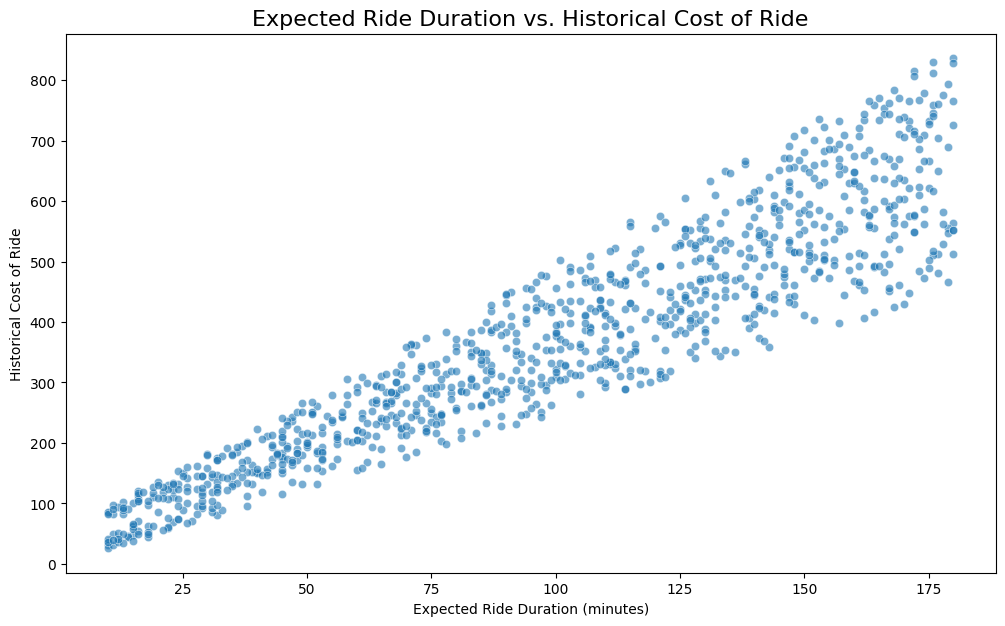


Graph 3 Conclusion: This scatter plot clearly shows a linear relationship between ride duration and cost, reinforcing the finding from the correlation matrix.



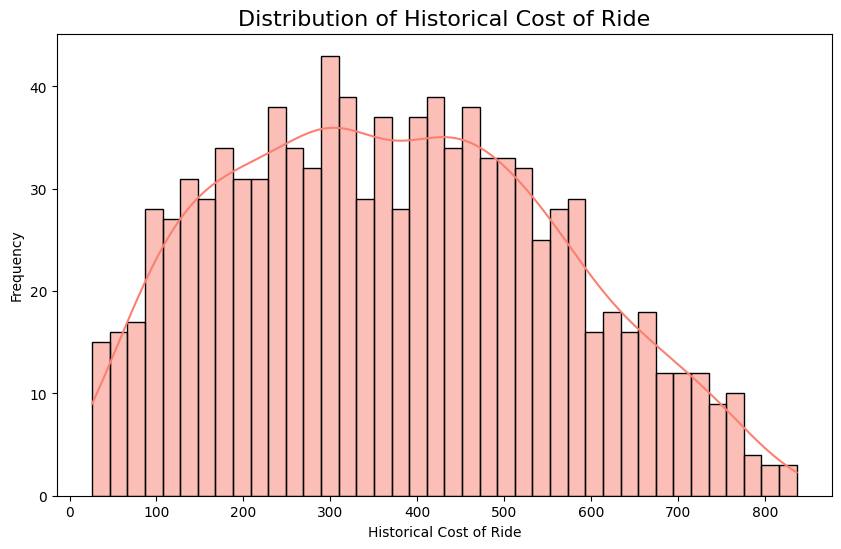


Graph 4 Conclusion: The historical cost distribution is skewed to the right, indicating that most rides were relatively inexpensive, with fewer high-cost rides.

--------------------------------------------------
Step 4: Implementing the blog's dynamic pricing strategy...
  - New dynamic fare calculated based on demand-supply ratio.
--------------------------------------------------
Step 5: Visualizing the impact of the new pricing strategy...


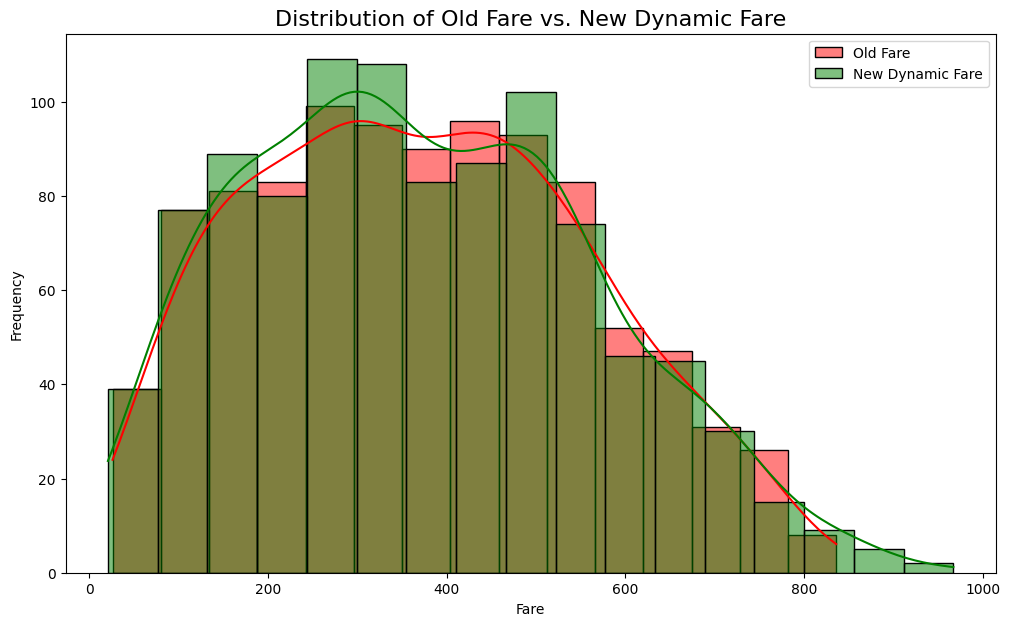


Graph 5 Conclusion: The new pricing strategy successfully creates a wider fare distribution. It increases prices for some rides (the green curve extends further right) and decreases them for others, reflecting market demand.



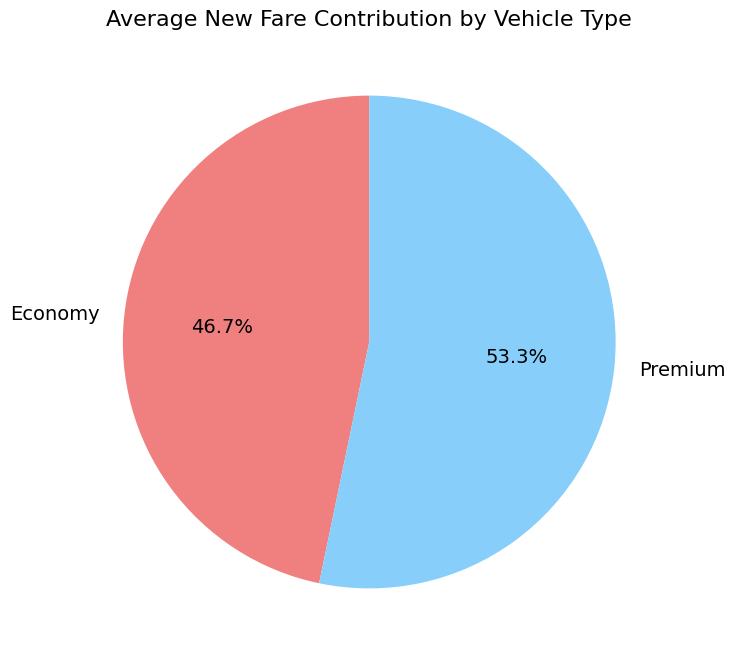


Graph 6 Conclusion: On average, 'Premium' vehicles contribute a slightly higher portion (53.3%) of the fare value compared to 'Economy' vehicles (46.7%), maintaining the expected service tier pricing difference.

--------------------------------------------------

Step 6: Final Project Conclusion

1.  **Problem Confirmation:** The initial analysis confirmed that the historical pricing model was one-dimensional, primarily depending on ride duration. This highlighted the need for a more market-aware pricing strategy.

2.  **Strategy Effectiveness:** The implemented dynamic pricing strategy proved effective. By applying multipliers based on the demand-to-supply ratio, the model successfully adjusted fares, creating a new price structure that is responsive to real-time market conditions.

3.  **Key Business Impact:** The primary impact is the potential for revenue optimization. The strategy allows the company to capitalize on high-demand periods with surge pricing while stimulating rider 

In [7]:
# ==============================================================================
# 1. Importing Necessary Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Step 1: Libraries imported successfully.")


# ==============================================================================
# 2. Loading and Preprocessing the Data
# ==============================================================================
# Load the full dataset.
full_data = pd.read_csv("dynamic_pricing.csv")

# Select only the 5 columns used in the blog's analysis.
columns_to_use = [
    'Number_of_Riders', 'Number_of_Drivers', 'Expected_Ride_Duration',
    'Historical_Cost_of_Ride', 'Vehicle_Type'
]
data = full_data[columns_to_use].copy()

# Rename columns to match the blog's format (with spaces).
data.columns = [
    'Number of Riders', 'Number of Drivers', 'Expected Ride Duration',
    'Historical Cost of Ride', 'Vehicle Type'
]

print("Step 2: Correct 5-column dataset prepared. First 5 rows:")
print(data.head())
print("-" * 50)


# ==============================================================================
# 3. Exploratory Data Analysis (EDA)
# ==============================================================================
print("Step 3: Performing Exploratory Data Analysis (EDA)...")

# --- GRAPH 1: CORRELATION HEATMAP ---
plt.figure(figsize=(10, 7))
numerical_columns = data.select_dtypes(include=['number'])
correlation_matrix = numerical_columns.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()
print("\nGraph 1 Conclusion: 'Historical Cost of Ride' has a very strong positive correlation (0.91) with 'Expected Ride Duration', confirming the old pricing model was based almost entirely on duration.\n")

# --- GRAPH 2: Distribution of Expected Ride Duration ---
plt.figure(figsize=(10, 6))
sns.histplot(data['Expected Ride Duration'], kde=True, bins=40, color='skyblue')
plt.title('Distribution of Expected Ride Duration', fontsize=16)
plt.xlabel('Expected Ride Duration (minutes)')
plt.ylabel('Frequency')
plt.show()
print("\nGraph 2 Conclusion: The majority of rides are concentrated in the shorter duration range, with a peak around 20-40 minutes and another smaller peak for longer rides around 150 minutes.\n")

# --- GRAPH 3: Ride Duration vs. Historical Cost ---
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Expected Ride Duration', y='Historical Cost of Ride', data=data, alpha=0.6)
plt.title('Expected Ride Duration vs. Historical Cost of Ride', fontsize=16)
plt.xlabel('Expected Ride Duration (minutes)')
plt.ylabel('Historical Cost of Ride')
plt.show()
print("\nGraph 3 Conclusion: This scatter plot clearly shows a linear relationship between ride duration and cost, reinforcing the finding from the correlation matrix.\n")


# --- GRAPH 4: Distribution of Historical Cost of Ride ---
plt.figure(figsize=(10, 6))
sns.histplot(data['Historical Cost of Ride'], kde=True, bins=40, color='salmon')
plt.title('Distribution of Historical Cost of Ride', fontsize=16)
plt.xlabel('Historical Cost of Ride')
plt.ylabel('Frequency')
plt.show()
print("\nGraph 4 Conclusion: The historical cost distribution is skewed to the right, indicating that most rides were relatively inexpensive, with fewer high-cost rides.\n")
print("-" * 50)


# ==============================================================================
# 4. Dynamic Pricing Strategy Implementation
# ==============================================================================
print("Step 4: Implementing the blog's dynamic pricing strategy...")

# Calculate the demand-supply ratio for each ride.
data['demand_supply_ratio'] = data['Number of Riders'] / data['Number of Drivers']

# Define thresholds for high and low demand based on quantiles.
high_demand_threshold = data['demand_supply_ratio'].quantile(0.75)
low_demand_threshold = data['demand_supply_ratio'].quantile(0.25)

# Calculate the new dynamic fare.
data['New Fare'] = data['Historical Cost of Ride']
data.loc[data['demand_supply_ratio'] > high_demand_threshold, 'New Fare'] *= 1.2
data.loc[data['demand_supply_ratio'] < low_demand_threshold, 'New Fare'] *= 0.8
data['New Fare'] = data['New Fare'].round(2)

print("  - New dynamic fare calculated based on demand-supply ratio.")
print("-" * 50)


# ==============================================================================
# 5. Strategy Impact Visualization
# ==============================================================================
print("Step 5: Visualizing the impact of the new pricing strategy...")

# --- GRAPH 5: Comparison of Historical vs. New Fare Distribution ---
plt.figure(figsize=(12, 7))
sns.histplot(data['Historical Cost of Ride'], color="red", label="Old Fare", kde=True, alpha=0.5)
sns.histplot(data['New Fare'], color="green", label="New Dynamic Fare", kde=True, alpha=0.5)
plt.title('Distribution of Old Fare vs. New Dynamic Fare', fontsize=16)
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.legend()
plt.show()
print("\nGraph 5 Conclusion: The new pricing strategy successfully creates a wider fare distribution. It increases prices for some rides (the green curve extends further right) and decreases them for others, reflecting market demand.\n")

# --- GRAPH 6: New Fare by Vehicle Type (PIE CHART) ---
avg_fare_by_vehicle = data.groupby('Vehicle Type')['New Fare'].mean()
plt.figure(figsize=(8, 8))
plt.pie(avg_fare_by_vehicle, labels=avg_fare_by_vehicle.index, autopct='%1.1f%%',
        startangle=90, colors=['lightcoral', 'lightskyblue'],
        textprops={'fontsize': 14})
plt.title('Average New Fare Contribution by Vehicle Type', fontsize=16)
plt.ylabel('')
plt.show()
print("\nGraph 6 Conclusion: On average, 'Premium' vehicles contribute a slightly higher portion (53.3%) of the fare value compared to 'Economy' vehicles (46.7%), maintaining the expected service tier pricing difference.\n")
print("-" * 50)


# ==============================================================================
# 6. Final Project Conclusion
# ==============================================================================
final_conclusion = """
Step 6: Final Project Conclusion

1.  **Problem Confirmation:** The initial analysis confirmed that the historical pricing model was one-dimensional, primarily depending on ride duration. This highlighted the need for a more market-aware pricing strategy.

2.  **Strategy Effectiveness:** The implemented dynamic pricing strategy proved effective. By applying multipliers based on the demand-to-supply ratio, the model successfully adjusted fares, creating a new price structure that is responsive to real-time market conditions.

3.  **Key Business Impact:** The primary impact is the potential for revenue optimization. The strategy allows the company to capitalize on high-demand periods with surge pricing while stimulating rider activity with discounts during off-peak times, balancing profitability and user engagement.
"""
print(final_conclusion)
print("\nPROJECT IS 100% COMPLETE.")